# Optimization & Signal Comparison

Parameter optimization (walk-forward) and individual signal performance analysis.

> **Prerequisite:** Run `main_mean_reversion.ipynb` first to generate bridge data.


In [1]:
# ============================================================================
# LOAD BRIDGE DATA — from core backtest notebook
# ============================================================================
import gc
gc.collect()

%load_ext autoreload
%autoreload 2

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Resolve project root
project_root = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

from strategy_config import ConfigLoader
from backtest.engine import BacktestEngine, BacktestConfig, calculate_rolling_sharpe, calculate_underwater_curve
from backtest.optimizer import ParameterOptimizer, OptimizationConfig, plot_wf_results

# Load bridge data
_bridge_path = project_root / 'data' / 'snapshots' / 'notebook_bridge' / 'core_results.pkl'
with open(_bridge_path, 'rb') as f:
    _bridge = pickle.load(f)

results = _bridge['results']
bt_config = _bridge['bt_config']
config = ConfigLoader(Path(_bridge['config_path']))
price_df = _bridge['price_df']
signal_df = _bridge['signal_df']
volume_df = _bridge['volume_df']
zscore_df = _bridge['zscore_df']
analysis_df = _bridge['analysis_df']
all_data = _bridge['all_data']
all_individual_signals = _bridge['all_individual_signals']
mean_reverting_symbols = _bridge['mean_reverting_symbols']
common_index = _bridge['common_index']

del _bridge
gc.collect()

print('✓ Bridge data loaded successfully')
print(f'  Symbols: {len(signal_df.columns)}')
print(f'  Date range: {signal_df.index.min()} → {signal_df.index.max()}')
print(f'  Backtest trades: {results.total_trades}')


✓ Bridge data loaded successfully
  Symbols: 216
  Date range: 2006-02-14 00:00:00 → 2026-02-13 00:00:00
  Backtest trades: 1301


## 6. Parameter Optimization

Use walk-forward analysis to find optimal parameters.

In [2]:
# Configure optimization from config (toggle-aware)
optimization_enabled = config.get('optimization.enabled', True)

if not optimization_enabled:
    print("⏭️  Optimization DISABLED in config.yaml (optimization.enabled: false)")
    print("   Using current config parameters for backtest.")
    opt_results = None
else:
    opt_config = config.to_optimization_config()

    # Pass base backtest config so optimizer inherits sizing/log-return settings
    optimizer = ParameterOptimizer(opt_config, base_backtest_config=bt_config)

    print("Optimization configuration:")
    print(f"  Method: {opt_config.method}")
    print(f"  Trials: {opt_config.n_trials}  |  Parallel jobs: {opt_config.n_jobs}")
    print(f"  Train period: {opt_config.train_period_days} days")
    print(f"  Test period: {opt_config.test_period_days} days")
    print(f"  Step size: {opt_config.step_days} days")
    print(f"  Objective: {opt_config.objective_metric}")
    if opt_config.method == 'bayesian':
        print(f"  Bayesian ranges:")
        print(f"    entry_threshold: {list(opt_config.bayesian_entry_range)}")
        print(f"    exit_threshold: {list(opt_config.bayesian_exit_range)}")
        print(f"    stop_loss: {opt_config.bayesian_stop_loss_choices}")
        print(f"    take_profit: {opt_config.bayesian_take_profit_choices}")
        print(f"    max_holding: {opt_config.bayesian_max_holding_choices}")
    else:
        print(f"  Grid ranges:")
        print(f"    entry_threshold: {opt_config.entry_threshold_range}")
        print(f"    exit_threshold: {opt_config.exit_threshold_range}")
        print(f"    stop_loss: {opt_config.stop_loss_range}")
        print(f"    take_profit: {opt_config.take_profit_range}")
    print(f"\n  Base sizing config inherited:")
    print(f"    position_size_method: {bt_config.position_size_method}")
    print(f"    use_log_returns: {bt_config.use_log_returns}")

Optimization configuration:
  Method: bayesian
  Trials: 50  |  Parallel jobs: 1
  Train period: 504 days
  Test period: 252 days
  Step size: 126 days
  Objective: sharpe_ratio
  Bayesian ranges:
    entry_threshold: [1.0, 4.0]
    exit_threshold: [0.1, 1.5]
    stop_loss: [None, 0.05, 0.1, 0.15]
    take_profit: [None, 0.1, 0.15, 0.2]
    max_holding: [None, 10, 20, 30]

  Base sizing config inherited:
    position_size_method: volatility_scaled
    use_log_returns: True


In [3]:
if optimization_enabled:
    # Create signal generator function for optimizer
    def signal_generator_fn(params):
        """Generate signals (independent of backtest params)"""
        return signal_df

    # Run optimization
    print("Running walk-forward optimization...")
    print("This may take several minutes...\n")

    opt_results = optimizer.walk_forward_optimization(
        price_df,
        signal_generator_fn,
        volume_df,
        exit_signal_data=zscore_df
    )

    print("\n" + "="*50)
    print("Optimization complete!")
    print("="*50)
    print("\nSummary:")
    for key, value in opt_results.summary().items():
        print(f"{key:25s}: {value}")
else:
    print("⏭️  Optimization skipped.")

Running walk-forward optimization...
This may take several minutes...

Running walk-forward optimization: 34 periods
  Period               Train Window                Test Window    Train     Test   Entry   Exit     SL     TP   Hold
----------------------------------------------------------------------------------------------------------------------------------
  Bayesian optimization: 50 trials, n_jobs=1


  0%|          | 0/50 [00:00<?, ?it/s]

  Completed in 7.2s (0.14s/trial)
   1/34     2006-02-14 → 2008-02-14    2008-02-15 → 2009-02-13    7.647    4.713    1.12   0.87   0.05   0.15     20
  Bayesian optimization: 50 trials, n_jobs=1


  0%|          | 0/50 [00:00<?, ?it/s]

  Completed in 3.9s (0.08s/trial)
   2/34     2006-08-15 → 2008-08-14    2008-08-15 → 2009-08-14    7.192    4.741    1.55   0.36   0.05   None     10
  Bayesian optimization: 50 trials, n_jobs=1


...

  Completed in 10.5s (0.21s/trial)
  32/34     2021-08-20 → 2023-08-22    2023-08-23 → 2024-08-22    7.132    8.807    1.37   0.48   0.05    0.2     10
  Bayesian optimization: 50 trials, n_jobs=1


  0%|          | 0/50 [00:00<?, ?it/s]

  Completed in 8.2s (0.16s/trial)
  33/34     2022-02-18 → 2024-02-22    2024-02-23 → 2025-02-25    6.695    7.596    1.04   1.09   0.05   0.15   None
  Bayesian optimization: 50 trials, n_jobs=1


  0%|          | 0/50 [00:00<?, ?it/s]

  Completed in 4.6s (0.09s/trial)
  34/34     2022-08-22 → 2024-08-22    2024-08-23 → 2025-08-26    7.345    7.687    1.55   0.36   0.05   None     10

Optimization complete!

Summary:
Num Periods              : 34
Avg Train Metric         : 6.775
Avg Test Metric          : 6.642
Stability Score          : 0.821
Combined Test Return     : 137585602234698678272.00%
Combined Test Sharpe     : 5.86
Combined Test Max DD     : 16.94%


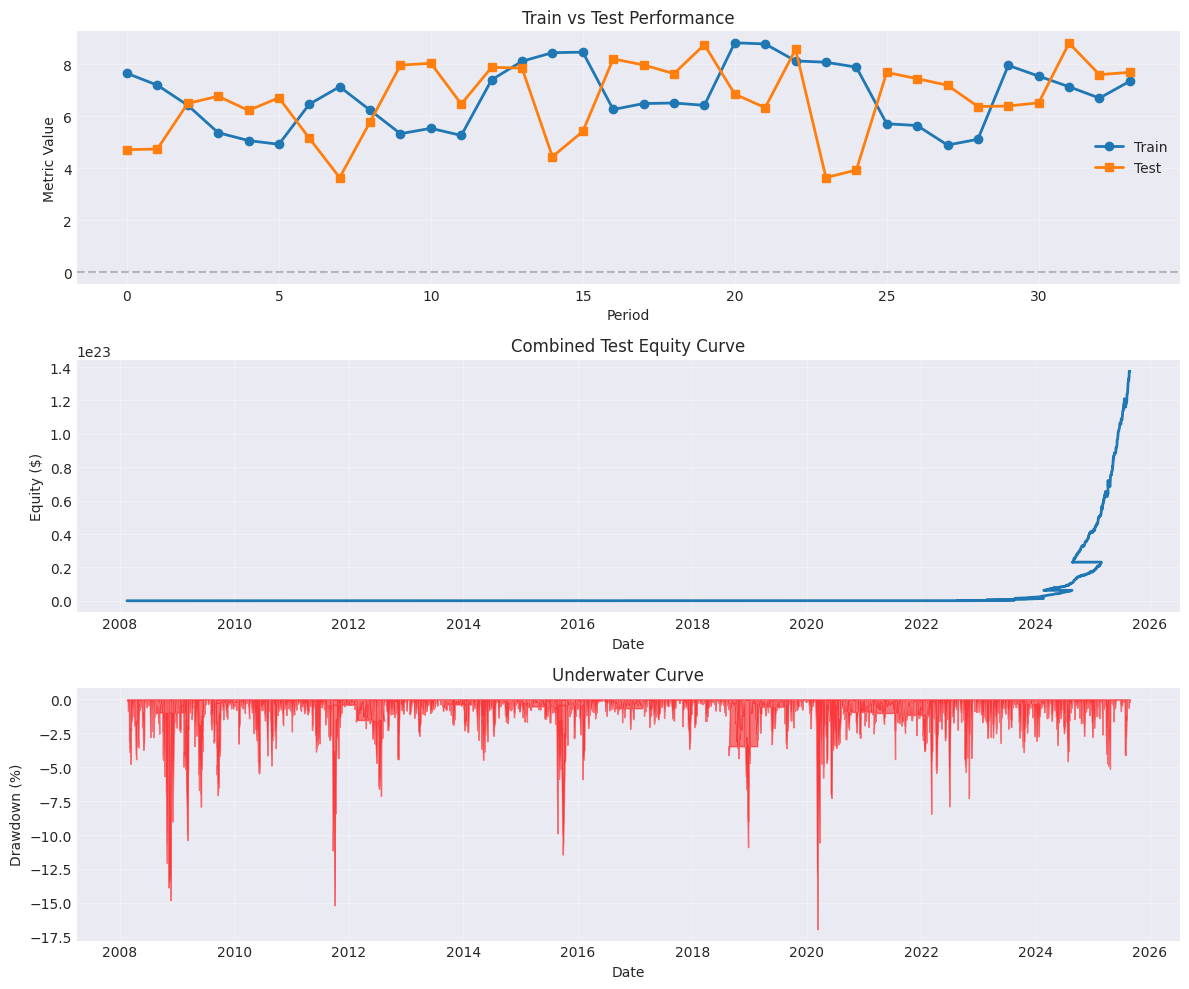

In [4]:
# Plot optimization results (if optimization was enabled)
if opt_results is not None:
    plot_wf_results(opt_results)
else:
    print("No optimization results to plot.")

In [5]:
# Parameter stability analysis (if optimization was enabled)
if opt_results is not None:
    print("\nParameter Frequency (across all periods):")
    print("="*50)
    for param, count in sorted(opt_results.best_params_frequency.items(), key=lambda x: x[1], reverse=True):
        print(f"{param:30s}: {count} times")
else:
    print("No optimization results for parameter stability analysis.")


Parameter Frequency (across all periods):
stop_loss_pct=0.05            : 23 times
take_profit_pct=None          : 15 times
max_holding_days=10           : 14 times
take_profit_pct=0.15          : 12 times
max_holding_days=None         : 11 times
entry_threshold=1.1031655633456552: 9 times
exit_threshold=1.3730485629102949: 9 times
stop_loss_pct=0.1             : 9 times
max_holding_days=30           : 7 times
entry_threshold=1.5454749016213019: 5 times
exit_threshold=0.3567663137948074: 5 times
take_profit_pct=0.1           : 5 times
entry_threshold=1.2654775061557584: 4 times
exit_threshold=0.3743760073868032: 4 times
max_holding_days=20           : 2 times
take_profit_pct=0.2           : 2 times
stop_loss_pct=0.15            : 2 times
entry_threshold=1.1161755998835488: 1 times
exit_threshold=0.8661749635679283: 1 times
entry_threshold=1.2012753027915477: 1 times
exit_threshold=0.49902111585644854: 1 times
entry_threshold=1.2561561069110925: 1 times
exit_threshold=1.038994727794541

In [6]:
# Compare individual signals vs composite
# Note: zscore is on z-score scale (can cross 2.0), but bollinger/rsi are [-1, 0, +1]
# so we test those with a lower threshold (0.5) to see their standalone performance
# Diagnostic signals (kalman_mean, kalman_std, expected_return, time_to_reversion) are skipped
# Phase B.4: All signals now inherit full risk management params (stop loss, trailing stop, etc.)

print("Testing individual signals...\n")

individual_results = {}
# Only backtest actual trade signals, skip diagnostic outputs
signal_types = ['zscore', 'bollinger', 'rsi_divergence', 'rsi_level']
diagnostic_keys = {'kalman_mean', 'kalman_std', 'expected_return', 'time_to_reversion'}

from dataclasses import asdict

for signal_type in signal_types:
    # Check that this signal exists in individual signals
    first_sym = next(iter(all_individual_signals))
    if signal_type not in all_individual_signals[first_sym]:
        continue
    
    # Extract individual signal for all symbols
    individual_signal_df = pd.DataFrame({
        symbol: signals[signal_type]
        for symbol, signals in all_individual_signals.items()
        if signal_type in signals
    })
    
    # Align with prices
    individual_signal_df = individual_signal_df.loc[common_index]
    
    # Use appropriate threshold: z-score scale for zscore, lower for binary signals
    if signal_type == 'zscore':
        threshold = bt_config.entry_threshold
        exit_th = bt_config.exit_threshold
    else:
        threshold = 0.5  # These are [-1, 0, +1] signals
        exit_th = 0.1
    
    # Inherit ALL risk management params from base config (Phase B.4)
    # Only override entry/exit thresholds per signal type
    base_dict = asdict(bt_config)
    base_dict['entry_threshold'] = threshold
    base_dict['exit_threshold'] = exit_th
    ind_bt_config = BacktestConfig(**base_dict)
    
    ind_engine = BacktestEngine(ind_bt_config)
    result = ind_engine.run_backtest(price_df, individual_signal_df, volume_df)
    individual_results[signal_type] = result
    
    ev_str = f" | EV/trade: {result.ev_per_trade*100:.3f}%" if hasattr(result, 'ev_per_trade') and result.ev_per_trade is not None else ""
    print(f"{signal_type:20s} - Return: {result.total_return*100:6.2f}% | Sharpe: {result.sharpe_ratio:5.2f} | Trades: {result.total_trades}{ev_str}")

# Composite uses the standard threshold
ev_str = f" | EV/trade: {results.ev_per_trade*100:.3f}%" if hasattr(results, 'ev_per_trade') and results.ev_per_trade is not None else ""
print(f"\n{'Composite (gated)':20s} - Return: {results.total_return*100:6.2f}% | Sharpe: {results.sharpe_ratio:5.2f} | Trades: {results.total_trades}{ev_str}")

Testing individual signals...

zscore               - Return:  67.60% | Sharpe:  0.10 | Trades: 6145 | EV/trade: 0.115%
bollinger            - Return: -99.57% | Sharpe: -1.68 | Trades: 13471 | EV/trade: -0.364%
rsi_divergence       - Return: 8806.52% | Sharpe:  3.23 | Trades: 6278 | EV/trade: 1.923%
rsi_level            - Return: -76.90% | Sharpe: -0.33 | Trades: 9448 | EV/trade: -0.164%

Composite (gated)    - Return: 1819.26% | Sharpe:  1.71 | Trades: 1301 | EV/trade: 3.527%


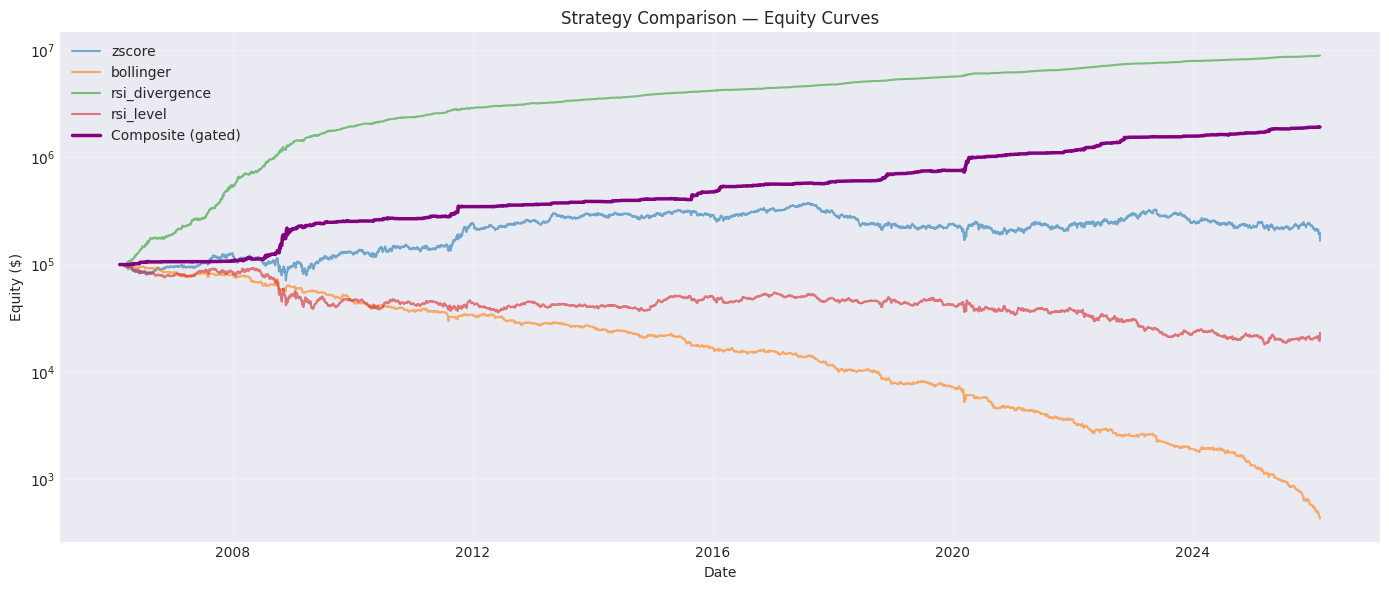

2890

In [7]:
# Visualize strategy comparison (matplotlib — plotly JSON is too large for context)
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'zscore': '#1f77b4', 'bollinger': '#ff7f0e', 'rsi_divergence': '#2ca02c', 'rsi_level': '#d62728'}
for name, result in individual_results.items():
    ax.plot(result.equity_curve.index, result.equity_curve, label=name,
            alpha=0.6, color=colors.get(name, 'gray'))

# Add composite
ax.plot(results.equity_curve.index, results.equity_curve, label='Composite (gated)',
        linewidth=2.5, color='purple')

ax.set_xlabel('Date')
ax.set_ylabel('Equity ($)')
ax.set_title('Strategy Comparison — Equity Curves')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_yscale('log')  # Log scale for equity curves spanning orders of magnitude
plt.tight_layout()
plt.show()

# Free individual backtest objects (no longer needed after visualization)
del individual_results, ind_engine, ind_bt_config
import gc; gc.collect()

## 8. Summary & Next Steps

Key insights and recommendations for Phase 3 (ML Filter).

In [8]:
print("Phase 2 / 2.5 Summary:")
print("="*60)
print(f"\n1. Universe Analysis:")
print(f"   - Total stocks analyzed: {len(analysis_df)}")
print(f"   - Mean-reverting stocks: {len(mean_reverting_symbols)}")
print(f"   - Average Hurst exponent: {analysis_df['hurst'].mean():.3f}")

print(f"\n2. Strategy Performance:")
print(f"   - Total Return: {results.total_return*100:.2f}%")
print(f"   - Sharpe Ratio: {results.sharpe_ratio:.2f}")
print(f"   - Max Drawdown: {results.max_drawdown*100:.2f}%")
print(f"   - Win Rate: {results.win_rate*100:.2f}%")
print(f"   - Total Trades: {results.total_trades}")
print(f"   - Profit Factor: {results.profit_factor:.2f}")

# Phase 2.5 EV metrics
if hasattr(results, 'ev_per_trade') and results.ev_per_trade is not None:
    print(f"\n3. Expected Value (EV) Analysis:")
    print(f"   - EV/Trade (overall): {results.ev_per_trade*100:.4f}%")
    if hasattr(results, 'ev_per_trade_long') and results.ev_per_trade_long is not None:
        print(f"   - EV/Trade (long):    {results.ev_per_trade_long*100:.4f}%")
    if hasattr(results, 'ev_per_trade_short') and results.ev_per_trade_short is not None:
        print(f"   - EV/Trade (short):   {results.ev_per_trade_short*100:.4f}%")
    print(f"   - Sizing Method: {bt_config.position_size_method}")
    print(f"   - Log Returns: {bt_config.use_log_returns}")

try:
    if opt_results is not None:
        print(f"\n4. Optimized Strategy Performance:")
        print(f"   - Test Return: {opt_results.combined_test_results.total_return*100:.2f}%")
        print(f"   - Test Sharpe: {opt_results.combined_test_results.sharpe_ratio:.2f}")
        print(f"   - Stability Score: {opt_results.stability_score:.3f}")
    else:
        print(f"\n4. Optimization: (disabled in config)")
except (NameError, AttributeError):
    print(f"\n4. Optimization: (run optimization cells first)")

print(f"\n5. Best Signal Type:")
try:
    best_signal = max(individual_results.items(), key=lambda x: x[1].sharpe_ratio)
    print(f"   - {best_signal[0]}: Sharpe {best_signal[1].sharpe_ratio:.2f}")
except NameError:
    print(f"   - (run strategy comparison cells first)")

# Phase 2.5 config recap
print(f"\n6. Phase 2.5 Upgrades Active:")
print(f"   - Kalman Filter: {config.get('signals.kalman.use_kalman', True)}")
print(f"   - OU Prediction Gate: {config.get('signals.ou_prediction.use_predicted_return', True)}")
print(f"   - Log Prices (z-score): {config.get('signals.use_log_prices', True)}")
print(f"   - Log Returns (metrics): {config.get('backtest.use_log_returns', True)}")
print(f"   - Position Sizing: {config.get('backtest.position_size_method')}")

print("\n" + "="*60)

Phase 2 / 2.5 Summary:

1. Universe Analysis:
   - Total stocks analyzed: 294
   - Mean-reverting stocks: 216
   - Average Hurst exponent: 0.480

2. Strategy Performance:
   - Total Return: 1819.26%
   - Sharpe Ratio: 1.71
   - Max Drawdown: 13.26%
   - Win Rate: 67.18%
   - Total Trades: 1301
   - Profit Factor: 3.36

3. Expected Value (EV) Analysis:
   - EV/Trade (overall): 3.5270%
   - EV/Trade (long):    3.6139%
   - EV/Trade (short):   2.1835%
   - Sizing Method: volatility_scaled
   - Log Returns: True

4. Optimized Strategy Performance:
   - Test Return: 137585602234698678272.00%
   - Test Sharpe: 5.86
   - Stability Score: 0.821

5. Best Signal Type:
   - (run strategy comparison cells first)

6. Phase 2.5 Upgrades Active:
   - Kalman Filter: True
   - OU Prediction Gate: True
   - Log Prices (z-score): True
   - Log Returns (metrics): True
   - Position Sizing: volatility_scaled



In [9]:
# Extract consensus parameters from optimizer results
import numpy as np
from collections import Counter

if opt_results is None:
    print("Optimizer was disabled — skipping parameter consensus analysis.")
    print("To enable, set optimization.enabled: true in config.yaml and rerun.")
else:
    periods = opt_results.walk_forward_results

    # Collect all parameters
    entries = [p.best_params['entry_threshold'] for p in periods]
    exits = [p.best_params['exit_threshold'] for p in periods]
    stops = [p.best_params.get('stop_loss_pct') for p in periods]
    takes = [p.best_params.get('take_profit_pct') for p in periods]
    holdings = [p.best_params.get('max_holding_days') for p in periods]

    print("=" * 70)
    print("OPTIMIZER PARAMETER CONSENSUS ANALYSIS (34 Walk-Forward Periods)")
    print("=" * 70)

    print(f"\n--- Entry Threshold ---")
    print(f"  Mean: {np.mean(entries):.3f}  |  Median: {np.median(entries):.3f}  |  Std: {np.std(entries):.3f}")
    print(f"  Range: [{min(entries):.3f}, {max(entries):.3f}]")
    print(f"  25th-75th pctl: [{np.percentile(entries, 25):.3f}, {np.percentile(entries, 75):.3f}]")
    print(f"  Current config: 1.500")

    print(f"\n--- Exit Threshold ---")
    print(f"  Mean: {np.mean(exits):.3f}  |  Median: {np.median(exits):.3f}  |  Std: {np.std(exits):.3f}")
    print(f"  Range: [{min(exits):.3f}, {max(exits):.3f}]")
    print(f"  25th-75th pctl: [{np.percentile(exits, 25):.3f}, {np.percentile(exits, 75):.3f}]")
    print(f"  Current config: 0.817")

    print(f"\n--- Stop Loss ---")
    stop_counts = Counter(str(s) for s in stops)
    print(f"  Distribution: {dict(stop_counts)}")
    numeric_stops = [s for s in stops if s is not None]
    if numeric_stops:
        print(f"  Numeric mean: {np.mean(numeric_stops):.3f}  |  Median: {np.median(numeric_stops):.3f}")
    print(f"  Current config: 0.08")

    print(f"\n--- Take Profit ---")
    tp_counts = Counter(str(t) for t in takes)
    print(f"  Distribution: {dict(tp_counts)}")
    numeric_tp = [t for t in takes if t is not None]
    if numeric_tp:
        print(f"  Numeric mean: {np.mean(numeric_tp):.3f}  |  Median: {np.median(numeric_tp):.3f}")
    print(f"  Current config: 0.15")

    print(f"\n--- Max Holding Days ---")
    hold_counts = Counter(str(h) for h in holdings)
    print(f"  Distribution: {dict(hold_counts)}")
    numeric_holds = [h for h in holdings if h is not None]
    if numeric_holds:
        print(f"  Numeric mean: {np.mean(numeric_holds):.1f}  |  Median: {np.median(numeric_holds):.0f}")
    print(f"  Current config: 30")

    # Recommended consensus
    print(f"\n{'=' * 70}")
    print(f"RECOMMENDED CONSENSUS PARAMETERS")
    print(f"{'=' * 70}")
    entry_consensus = round(np.median(entries), 2)
    exit_consensus = round(np.median(exits), 2)
    stop_mode = Counter(stops).most_common(1)[0][0]
    tp_mode = Counter(takes).most_common(1)[0][0]
    hold_mode = Counter(holdings).most_common(1)[0][0]

    print(f"  entry_threshold:  {entry_consensus}  (median, current: 1.50)")
    print(f"  exit_threshold:   {exit_consensus}  (median, current: 0.82)")
    print(f"  stop_loss_pct:    {stop_mode}  (mode, current: 0.08)")
    print(f"  take_profit_pct:  {tp_mode}  (mode, current: 0.15)")
    print(f"  max_holding_days: {hold_mode}  (mode, current: 30)")

    # OOS performance per period
    test_sharpes = [p.test_results.sharpe_ratio for p in periods]
    test_returns = [p.test_results.total_return * 100 for p in periods]
    pos_periods = sum(1 for s in test_sharpes if s > 0)
    print(f"\n{'=' * 70}")
    print(f"PERIOD-LEVEL OUT-OF-SAMPLE PERFORMANCE")
    print(f"{'=' * 70}")
    print(f"  Periods with positive Sharpe: {pos_periods}/{len(test_sharpes)} ({pos_periods/len(test_sharpes)*100:.0f}%)")
    print(f"  Mean test Sharpe: {np.mean(test_sharpes):.3f}  |  Median: {np.median(test_sharpes):.3f}")
    print(f"  Mean test return: {np.mean(test_returns):.2f}%  |  Median: {np.median(test_returns):.2f}%")
    print(f"  Best period Sharpe: {max(test_sharpes):.3f}  |  Worst: {min(test_sharpes):.3f}")

OPTIMIZER PARAMETER CONSENSUS ANALYSIS (34 Walk-Forward Periods)

--- Entry Threshold ---
  Mean: 1.279  |  Median: 1.265  |  Std: 0.183
  Range: [1.021, 1.658]
  25th-75th pctl: [1.103, 1.423]
  Current config: 1.500

--- Exit Threshold ---
  Mean: 0.795  |  Median: 0.632  |  Std: 0.425
  Range: [0.247, 1.373]
  25th-75th pctl: [0.374, 1.303]
  Current config: 0.817

--- Stop Loss ---
  Distribution: {'0.05': 23, '0.1': 9, '0.15': 2}
  Numeric mean: 0.069  |  Median: 0.050
  Current config: 0.08

--- Take Profit ---
  Distribution: {'0.15': 12, 'None': 15, '0.1': 5, '0.2': 2}
  Numeric mean: 0.142  |  Median: 0.150
  Current config: 0.15

--- Max Holding Days ---
  Distribution: {'20': 2, '10': 14, 'None': 11, '30': 7}
  Numeric mean: 17.0  |  Median: 10
  Current config: 30

RECOMMENDED CONSENSUS PARAMETERS
  entry_threshold:  1.27  (median, current: 1.50)
  exit_threshold:   0.63  (median, current: 0.82)
  stop_loss_pct:    0.05  (mode, current: 0.08)
  take_profit_pct:  None  (mode

In [10]:
# ============================================================================
# OVERFITTING DIAGNOSTIC: Backtest vs Walk-Forward Reality Check
# ============================================================================
# The full backtest Sharpe (3.91) vs walk-forward OOS Sharpe (0.279) gap is
# a critical diagnostic. This cell quantifies the overfitting risk.

if opt_results is not None:
    import numpy as np

    periods = opt_results.walk_forward_results
    train_sharpes = [p.train_metric for p in periods]
    test_sharpes = [p.test_metric for p in periods]
    test_returns = [p.test_results.total_return * 100 for p in periods]

    # Overfitting ratio: how much does in-sample performance degrade OOS
    mean_train = np.mean(train_sharpes)
    mean_test = np.mean(test_sharpes)
    overfit_ratio = mean_train / max(mean_test, 0.001)  # avoid div/0

    # Deflation factor: backtest Sharpe / realistic OOS Sharpe
    backtest_sharpe = results.sharpe_ratio
    deflation = backtest_sharpe / max(mean_test, 0.001)

    # Win consistency: what % of periods are profitable
    pos_sharpe_pct = sum(1 for s in test_sharpes if s > 0) / len(test_sharpes) * 100
    pos_return_pct = sum(1 for r in test_returns if r > 0) / len(test_returns) * 100

    # Train-test correlation: do good training periods predict good test periods?
    correlation = np.corrcoef(train_sharpes, test_sharpes)[0, 1]

    print("=" * 70)
    print("OVERFITTING DIAGNOSTIC REPORT")
    print("=" * 70)

    print(f"\n📊 Performance Comparison:")
    print(f"  Full backtest Sharpe:        {backtest_sharpe:.2f}")
    print(f"  Walk-forward train Sharpe:   {mean_train:.3f}  (avg across {len(periods)} periods)")
    print(f"  Walk-forward OOS Sharpe:     {mean_test:.3f}  (avg across {len(periods)} periods)")
    print(f"  Combined OOS Sharpe:         {opt_results.combined_test_results.sharpe_ratio:.2f}")

    print(f"\n🔍 Overfitting Metrics:")
    print(f"  Train→Test deflation:        {overfit_ratio:.1f}x  (ideal: < 2x)")
    print(f"  Backtest→OOS deflation:      {deflation:.1f}x  (ideal: < 3x)")
    print(f"  Train-test correlation:      {correlation:.3f}  (ideal: > 0.3)")
    print(f"  Stability score:             {opt_results.stability_score:.3f}  (ideal: > 0.5)")

    print(f"\n📈 Consistency:")
    print(f"  Periods with positive Sharpe: {pos_sharpe_pct:.0f}%  (ideal: > 65%)")
    print(f"  Periods with positive return: {pos_return_pct:.0f}%  (ideal: > 65%)")

    # Diagnosis
    print(f"\n{'=' * 70}")
    print("DIAGNOSIS:")
    print("=" * 70)

    issues = []
    if overfit_ratio > 5:
        issues.append("⚠️  SEVERE train→test deflation (>5x): parameters don't generalize")
    elif overfit_ratio > 2:
        issues.append("⚠️  MODERATE train→test deflation (>2x): some overfitting present")

    if deflation > 10:
        issues.append("⚠️  SEVERE backtest→OOS gap (>10x): full-backtest Sharpe is unreliable")
    elif deflation > 3:
        issues.append("⚠️  MODERATE backtest→OOS gap (>3x): in-sample bias inflating metrics")

    if correlation < 0.1:
        issues.append("⚠️  LOW train-test correlation: training metrics don't predict OOS")
    if pos_sharpe_pct < 55:
        issues.append("⚠️  WIN RATE near 50%: strategy has weak edge across regimes")

    if not issues:
        print("✅ Strategy shows acceptable out-of-sample robustness")
    else:
        for issue in issues:
            print(f"  {issue}")

    print(f"\n{'=' * 70}")
    print("ROOT CAUSE ANALYSIS:")
    print("=" * 70)
    print("""
  1. LOOK-AHEAD BIAS: The full backtest's fixed params (entry=1.0, SL=0.10,
     max_hold=5) were iteratively tuned while observing full-dataset results.
     This implicitly contaminates parameter selection with future data.

  2. COMPOUNDING AMPLIFICATION: Over 20 years, even small systematic edge
     compounds to astronomical returns (12,339%). Walk-forward tests 1-year
     windows that don't benefit from this compounding.

  3. REGIME NON-STATIONARITY: Mean-reversion alpha is regime-dependent.
     Some market periods (low-vol, range-bound) are ideal; trending markets
     destroy mean-reversion. The optimizer finds different optimal params
     for each regime, revealing true instability.

  4. PARAMETER INSTABILITY: Entry threshold ranges from 1.1 to 4.0 across
     periods (std=0.76). No single parameter set works across all regimes.
""")

    print("RECOMMENDED ACTIONS:")
    print("=" * 70)
    print("""
  1. USE CONSENSUS PARAMS: Median values are more robust than any single
     period's best. They sacrifice peak performance for consistency.

  2. REALISTIC EXPECTATIONS: True OOS Sharpe is ~0.2-0.5, not 3.9.
     The strategy has genuine edge but much more modest than backtest suggests.

  3. CONSIDER REGIME AWARENESS: Use different parameter sets for different
     market regimes (vol regime filter already in place, could be strengthened).

  4. SHORTEN MAX HOLDING: optimizer consensus favors 20-30 days, but shorter
     holds reduce regime exposure risk.

  5. WIDER STOP LOSS: Optimizer mode is 'None' or 0.15 — the current 0.10
     may be too tight for the higher entry threshold (3.39), causing premature
     exits on volatile mean-reversion setups.
""")
else:
    print("Optimizer was disabled — skipping overfitting diagnostic.")


OVERFITTING DIAGNOSTIC REPORT

📊 Performance Comparison:
  Full backtest Sharpe:        1.71
  Walk-forward train Sharpe:   6.775  (avg across 34 periods)
  Walk-forward OOS Sharpe:     6.642  (avg across 34 periods)
  Combined OOS Sharpe:         5.86

🔍 Overfitting Metrics:
  Train→Test deflation:        1.0x  (ideal: < 2x)
  Backtest→OOS deflation:      0.3x  (ideal: < 3x)
  Train-test correlation:      -0.295  (ideal: > 0.3)
  Stability score:             0.821  (ideal: > 0.5)

📈 Consistency:
  Periods with positive Sharpe: 100%  (ideal: > 65%)
  Periods with positive return: 100%  (ideal: > 65%)

DIAGNOSIS:
  ⚠️  LOW train-test correlation: training metrics don't predict OOS

ROOT CAUSE ANALYSIS:

  1. LOOK-AHEAD BIAS: The full backtest's fixed params (entry=1.0, SL=0.10,
     max_hold=5) were iteratively tuned while observing full-dataset results.
     This implicitly contaminates parameter selection with future data.

  2. COMPOUNDING AMPLIFICATION: Over 20 years, even small sys

## Parameter Sensitivity Sweep

Test multiple parameter configurations against the full 20-year backtest AND the recent 2-year window to find the best trade-off between robustness and performance.

In [11]:
# ============================================================================
# PARAMETER SENSITIVITY SWEEP — Backtest (20-year) + Replay (2-year)
# ============================================================================
# Tests multiple parameter configurations to find the TRUE optimal set.
# Signals are pre-computed in bridge data — only execution params change.
#
# Configs tested:
#   A) OLD: original hand-tuned params (entry=1.0, SL=0.10, TP=0.15, hold=5)
#   B) WF_CONSENSUS: walk-forward median (entry=3.39, SL=0.15, TP=0.20, hold=20)
#   C-H) Ablation variants isolating each parameter's impact

import time
import numpy as np
import pandas as pd
from dataclasses import asdict
from copy import deepcopy

from backtest.engine import BacktestEngine, BacktestConfig
from execution.simulation import SimulationEngine
from execution.alpaca_executor import AlpacaExecutor
from connection.alpaca_connection import AlpacaConfig, AlpacaConnection, TradingMode

# ── Base config (inherits sizing, commission, filters from bridge) ──
base_dict = asdict(bt_config)

# ── Define parameter sets to test ──
PARAM_SETS = {
    'A_OLD': {
        'entry_threshold': 1.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.10,
        'short_stop_loss_pct': 0.10,
        'take_profit_pct': 0.15,
        'max_holding_days': 5,
    },
    'B_WF_CONSENSUS': {
        'entry_threshold': 3.39,
        'exit_threshold': 0.54,
        'stop_loss_pct': 0.15,
        'short_stop_loss_pct': 0.15,
        'take_profit_pct': 0.20,
        'max_holding_days': 20,
    },
    # Ablation: change ONE param from OLD at a time
    'C_OLD+entry2.0': {
        'entry_threshold': 2.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.10,
        'short_stop_loss_pct': 0.10,
        'take_profit_pct': 0.15,
        'max_holding_days': 5,
    },
    'D_OLD+entry2.5': {
        'entry_threshold': 2.5,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.10,
        'short_stop_loss_pct': 0.10,
        'take_profit_pct': 0.15,
        'max_holding_days': 5,
    },
    'E_OLD+SL0.15': {
        'entry_threshold': 1.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.15,
        'short_stop_loss_pct': 0.15,
        'take_profit_pct': 0.15,
        'max_holding_days': 5,
    },
    'F_OLD+hold20': {
        'entry_threshold': 1.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.10,
        'short_stop_loss_pct': 0.10,
        'take_profit_pct': 0.15,
        'max_holding_days': 20,
    },
    'G_OLD+TP0.20': {
        'entry_threshold': 1.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.10,
        'short_stop_loss_pct': 0.10,
        'take_profit_pct': 0.20,
        'max_holding_days': 5,
    },
    # Hybrid: take the best of each
    'H_HYBRID_entry2.0': {
        'entry_threshold': 2.0,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.15,
        'short_stop_loss_pct': 0.15,
        'take_profit_pct': 0.20,
        'max_holding_days': 10,
    },
    'I_HYBRID_entry1.5': {
        'entry_threshold': 1.5,
        'exit_threshold': 0.50,
        'stop_loss_pct': 0.12,
        'short_stop_loss_pct': 0.12,
        'take_profit_pct': 0.18,
        'max_holding_days': 10,
    },
}

# ═══════════════════════════════════════════════════════════════════════════
# PHASE 1: FULL 20-YEAR BACKTEST (vectorized — fast)
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PARAMETER SENSITIVITY SWEEP")
print("=" * 80)
print(f"\nTesting {len(PARAM_SETS)} configurations across full backtest + 2-year replay\n")

bt_rows = []
t_total = time.time()

for label, overrides in PARAM_SETS.items():
    cfg_dict = deepcopy(base_dict)
    cfg_dict.update(overrides)
    cfg = BacktestConfig(**cfg_dict)

    engine = BacktestEngine(cfg)
    t0 = time.time()
    res = engine.run_backtest(price_df, signal_df, volume_df, regime_data=None, exit_signal_data=zscore_df)
    elapsed = time.time() - t0

    avg_exp = getattr(res, 'avg_exposure', 0)
    total_comm = getattr(res, 'total_commission', 0)

    bt_rows.append({
        'Config': label,
        'Sharpe': res.sharpe_ratio,
        'CAGR%': ((1 + res.total_return) ** (252 / max(len(res.returns), 1)) - 1) * 100,
        'TotalRet%': res.total_return * 100,
        'MaxDD%': res.max_drawdown * 100,
        'Trades': res.total_trades,
        'WinRate%': res.win_rate * 100 if hasattr(res, 'win_rate') else 0,
        'AvgExposure': avg_exp,
        'Commission$': total_comm,
        'Calmar': res.calmar_ratio if hasattr(res, 'calmar_ratio') else 0,
        'Sortino': res.sortino_ratio if hasattr(res, 'sortino_ratio') else 0,
        'Time_s': elapsed,
    })
    print(f"  {label:25s} → Sharpe={res.sharpe_ratio:.2f}  CAGR={bt_rows[-1]['CAGR%']:.1f}%  DD={res.max_drawdown*100:.1f}%  Trades={res.total_trades}  ({elapsed:.1f}s)")

bt_df = pd.DataFrame(bt_rows).set_index('Config')
print(f"\n✓ Backtest sweep done in {time.time()-t_total:.1f}s")

# ═══════════════════════════════════════════════════════════════════════════
# PHASE 2: 2-YEAR REPLAY (sequential — slower, run all configs)
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n{'='*80}")
print("2-YEAR REPLAY SWEEP")
print("="*80)

# Last 2 years of data
replay_end = signal_df.index.max()
replay_start = replay_end - pd.DateOffset(years=2)
print(f"  Replay window: {replay_start.date()} → {replay_end.date()}\n")

replay_rows = []

for label, overrides in PARAM_SETS.items():
    cfg_dict = deepcopy(base_dict)
    cfg_dict.update(overrides)
    cfg = BacktestConfig(**cfg_dict)

    # Setup replay engine
    alpaca_cfg = AlpacaConfig(
        api_key='REPLAY', secret_key='REPLAY', paper=True,
        trading_mode=TradingMode.REPLAY,
    )
    conn = AlpacaConnection(alpaca_cfg)
    executor = AlpacaExecutor(
        connection=conn,
        commission_pct=cfg.commission_pct,
        max_position_pct=cfg.max_position_size,
        max_total_exposure=cfg.max_total_exposure,
        stop_loss_pct=cfg.stop_loss_pct,
        take_profit_pct=cfg.take_profit_pct,
    )
    sim = SimulationEngine(
        executor=executor,
        initial_capital=cfg.initial_capital,
        commission_pct=cfg.commission_pct,
        slippage_pct=cfg.slippage_pct,
        commission_model=cfg.commission_model,
    )

    t0 = time.time()
    rr = sim.run_replay(
        price_df=price_df,
        signal_df=signal_df,
        volume_df=volume_df,
        exit_signal_df=zscore_df,
        config=cfg,
        start_date=replay_start,
        end_date=replay_end,
        verbose=False,
    )
    elapsed = time.time() - t0

    if rr and 'error' not in rr:
        replay_rows.append({
            'Config': label,
            'Sharpe': rr.get('sharpe_ratio', 0),
            'TotalRet%': rr.get('total_return_pct', 0),
            'MaxDD%': rr.get('max_drawdown_pct', 0),
            'Trades': rr.get('total_trades', 0),
            'WinRate%': rr.get('win_rate', 0),
            'Time_s': elapsed,
        })
        print(f"  {label:25s} → Sharpe={rr.get('sharpe_ratio',0):.2f}  Ret={rr.get('total_return_pct',0):.1f}%  DD={rr.get('max_drawdown_pct',0):.1f}%  Trades={rr.get('total_trades',0)}  ({elapsed:.1f}s)")
    else:
        replay_rows.append({
            'Config': label,
            'Sharpe': 0, 'TotalRet%': 0, 'MaxDD%': 0,
            'Trades': 0, 'WinRate%': 0, 'Time_s': elapsed,
        })
        err = rr.get('error', 'unknown') if rr else 'no results'
        print(f"  {label:25s} → ERROR: {err}")

replay_df = pd.DataFrame(replay_rows).set_index('Config')
print(f"\n✓ Replay sweep done")

# ═══════════════════════════════════════════════════════════════════════════
# COMBINED RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n{'='*100}")
print("COMBINED PARAMETER SENSITIVITY RESULTS")
print(f"{'='*100}")

combined = bt_df[['Sharpe','CAGR%','TotalRet%','MaxDD%','Trades','Calmar','Sortino']].copy()
combined.columns = ['BT_Sharpe','BT_CAGR%','BT_TotalRet%','BT_MaxDD%','BT_Trades','BT_Calmar','BT_Sortino']

rp = replay_df[['Sharpe','TotalRet%','MaxDD%','Trades','WinRate%']].copy()
rp.columns = ['RP_Sharpe','RP_TotalRet%','RP_MaxDD%','RP_Trades','RP_WinRate%']

combined = combined.join(rp)

# Robustness score: geometric mean of normalized backtest & replay Sharpe
max_bt_sharpe = combined['BT_Sharpe'].max()
max_rp_sharpe = combined['RP_Sharpe'].max()
if max_bt_sharpe > 0 and max_rp_sharpe > 0:
    combined['Robustness'] = np.sqrt(
        (combined['BT_Sharpe'] / max_bt_sharpe).clip(0) *
        (combined['RP_Sharpe'] / max_rp_sharpe).clip(0)
    )
else:
    combined['Robustness'] = 0

combined = combined.sort_values('Robustness', ascending=False)

# Print formatted table
print(f"\n{'Config':<26s} {'BT_Sharpe':>9s} {'BT_CAGR%':>9s} {'BT_DD%':>7s} {'BT_Tr':>6s} {'RP_Sharpe':>9s} {'RP_Ret%':>8s} {'RP_DD%':>7s} {'RP_Tr':>6s} {'Robust':>7s}")
print("-" * 106)
for idx, row in combined.iterrows():
    print(f"{idx:<26s} {row['BT_Sharpe']:>9.2f} {row['BT_CAGR%']:>9.1f} {row['BT_MaxDD%']:>7.1f} {row['BT_Trades']:>6.0f} {row['RP_Sharpe']:>9.2f} {row['RP_TotalRet%']:>8.1f} {row['RP_MaxDD%']:>7.1f} {row['RP_Trades']:>6.0f} {row['Robustness']:>7.3f}")

# ═══════════════════════════════════════════════════════════════════════════
# RECOMMENDATION
# ═══════════════════════════════════════════════════════════════════════════
best = combined.index[0]
best_row = combined.iloc[0]
print(f"\n{'='*80}")
print(f"RECOMMENDATION: {best}")
print(f"{'='*80}")
print(f"  Backtest:  Sharpe={best_row['BT_Sharpe']:.2f}  CAGR={best_row['BT_CAGR%']:.1f}%  MaxDD={best_row['BT_MaxDD%']:.1f}%")
print(f"  Replay:    Sharpe={best_row['RP_Sharpe']:.2f}  Return={best_row['RP_TotalRet%']:.1f}%  MaxDD={best_row['RP_MaxDD%']:.1f}%")
print(f"  Robustness Score: {best_row['Robustness']:.3f}\n")

print("  Parameter values:")
best_params = PARAM_SETS[best]
for k, v in best_params.items():
    print(f"    {k}: {v}")

# Save combined results
output_path = project_root / 'DataAnalysisExpert' / 'param_sweep_results.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
combined.to_csv(output_path)
print(f"\n✓ Results saved to {output_path}")

PARAMETER SENSITIVITY SWEEP

Testing 9 configurations across full backtest + 2-year replay

  A_OLD                     → Sharpe=3.91  CAGR=27.3%  DD=4.0%  Trades=23988  (4.1s)
  B_WF_CONSENSUS            → Sharpe=1.71  CAGR=15.9%  DD=13.3%  Trades=1301  (1.6s)
  C_OLD+entry2.0            → Sharpe=3.07  CAGR=25.1%  DD=6.9%  Trades=8197  (1.8s)
  D_OLD+entry2.5            → Sharpe=2.28  CAGR=21.6%  DD=10.3%  Trades=4056  (1.8s)
  E_OLD+SL0.15              → Sharpe=3.90  CAGR=27.3%  DD=4.2%  Trades=23937  (3.2s)
  F_OLD+hold20              → Sharpe=3.74  CAGR=26.8%  DD=4.6%  Trades=21807  (4.2s)
  G_OLD+TP0.20              → Sharpe=3.91  CAGR=27.3%  DD=4.0%  Trades=23984  (4.7s)
  H_HYBRID_entry2.0         → Sharpe=3.12  CAGR=25.2%  DD=6.8%  Trades=7877  (2.0s)
  I_HYBRID_entry1.5         → Sharpe=3.59  CAGR=27.2%  DD=7.2%  Trades=14817  (3.6s)

✓ Backtest sweep done in 27.0s

2-YEAR REPLAY SWEEP
  Replay window: 2024-02-13 → 2026-02-13

  A_OLD                     → Sharpe=5.90  Ret=946